In [ ]:
import os, sys

current_dir = os.path.abspath("")
repo_path = os.path.abspath(
    os.path.join(
        current_dir, "..", "..", "reproduction", "2ABT_behaviour_models_updated"
    )
)
if repo_path not in sys.path:
    sys.path.append(repo_path)
import plot_models_v_mouse as pmm
import conditional_probs as cp
import model_simulations as sim

phase_3_path = os.path.abspath(os.path.join("..", "p3_model_comparison"))
if phase_3_path not in sys.path:
    sys.path.append(phase_3_path)
from nonlinear_stickiness_refined_v2 import (
    run_rflr_nonlinear_stickiness,
    run_hmm_nonlinear_stickiness,
    run_hmm_reset_nonlinear_stickiness,
    run_hmm_resetv2_nonlinear_stickiness,
    run_fq_nonlinear_stickiness,
    run_fq_value_gated_only,
)

import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from scipy.optimize import minimize
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import seaborn as sns
from collections import deque
import matplotlib.lines as mlines

In [ ]:
data_path = os.path.join(repo_path, "mouse_data.csv")
df = pd.read_csv(data_path)
cv_results = pd.read_csv(
    os.path.join("..", "p2_generative_fits", "cv_results_fitted.csv")
)

In [ ]:
def extract_sessions(df, condition):
    # Extracts sessions for a specific condition.
    # Returns:
    # sessions: List of (choices, rewards) tuples for model fitting
    # targets: List of true target states (0/1) for simulations
    subset = df[df["Condition"] == condition]
    sessions_list = []
    targets_list = []

    for sess_id, group in subset.groupby("Session"):
        # Sort by trial
        group = group.sort_values("Trial")

        c = group["Decision"].astype(int).values
        r = group["Reward"].astype(int).values
        state = group["Target"].astype(int).values

        sessions_list.append((c, r))
        targets_list.append(state)

    return sessions_list, targets_list

In [ ]:
def optimize_fold(model_type, train_sess, fixed_params):
    # Standard biological working-memory window for motor/value models
    n_steps_list = [1, 2, 3, 4, 5]

    # Expanded evidence-accumulation window for the cognitive model
    if model_type == "HMM_resetv2":
        n_steps_list = [1, 2, 3, 4, 5, 10, 15, 20]

    best_train_nll = np.inf
    best_params = None

    # Define bounds for (alpha_base, gamma)
    bounds = [(0.1, 5.0), (0.0, 5.0)]

    for n in n_steps_list:
        # FQ_Value_Gated does not use gamma, so we fix it to 0.0
        if model_type == "FQ_Value_Gated":
            initial_guess = [1.5]  # Only alpha_base
            fq_bounds = [(0.1, 5.0)]

            def objective(x):
                ab = x[0]
                # Pass 0.0 for gamma to maintain function signature compatibility
                ll = run_fq_value_gated_only(
                    train_sess,
                    (ab, fixed_params["k"], 1.0),
                    n,
                    0.0,
                    fit_mode=True,
                    return_ll_only=True,
                )
                return -ll

            res = minimize(
                objective, initial_guess, method="L-BFGS-B", bounds=fq_bounds
            )
            current_alpha, current_gamma = res.x[0], 0.0

        else:
            initial_guess = [1.5, 1.0]  # alpha_base and gamma

            def objective(x):
                ab, g = x
                if model_type == "RFLR":
                    ll = run_rflr_nonlinear_stickiness(
                        train_sess,
                        (ab, fixed_params["beta"], fixed_params["tau"]),
                        n,
                        g,
                        fit_mode=True,
                        return_ll_only=True,
                    )
                elif model_type == "HMM_sticky":
                    prms = {
                        "q": fixed_params["q"],
                        "p": fixed_params["p"],
                        "alpha": ab,
                        "beta": fixed_params["beta"],
                        "tau": fixed_params["tau"],
                    }
                    ll = run_hmm_nonlinear_stickiness(
                        train_sess, prms, n, g, fit_mode=True, return_ll_only=True
                    )
                elif model_type == "HMM_reset":
                    prms = {
                        "q": fixed_params["q"],
                        "p": fixed_params["p"],
                        "alpha": ab,
                        "beta": fixed_params["beta"],
                        "tau": fixed_params["tau"],
                    }
                    ll = run_hmm_reset_nonlinear_stickiness(
                        train_sess, prms, n, g, fit_mode=True, return_ll_only=True
                    )
                elif model_type == "HMM_resetv2":
                    prms = {
                        "q": fixed_params["q"],
                        "p": fixed_params["p"],
                        "alpha": ab,
                        "beta": fixed_params["beta"],
                        "tau": fixed_params["tau"],
                    }
                    ll = run_hmm_resetv2_nonlinear_stickiness(
                        train_sess, prms, n, g, fit_mode=True, return_ll_only=True
                    )
                elif model_type == "FQ":
                    ll = run_fq_nonlinear_stickiness(
                        train_sess,
                        (ab, fixed_params["k"], 1.0),
                        n,
                        g,
                        fit_mode=True,
                        return_ll_only=True,
                    )
                elif model_type == "FQ_Value_Gated":
                    ll = run_fq_value_gated_only(
                        train_sess,
                        (ab, fixed_params["k"], 1.0),
                        n,
                        g,
                        fit_mode=True,
                        return_ll_only=True,
                    )

                return -ll

            res = minimize(objective, initial_guess, method="L-BFGS-B", bounds=bounds)
            current_alpha, current_gamma = res.x[0], res.x[1]

        if res.fun < best_train_nll:
            best_train_nll = res.fun
            best_params = {
                "alpha_base": current_alpha,
                "gamma": current_gamma,
                "n_steps": n,
            }

    return best_params

In [ ]:
def _process_fold(train_idx, test_idx, sessions, model_type, fixed_params):
    train_sess = [sessions[i] for i in train_idx]
    test_sess = [sessions[i] for i in test_idx]

    best_p = optimize_fold(model_type, train_sess, fixed_params)

    if model_type == "RFLR":
        ll = run_rflr_nonlinear_stickiness(
            test_sess,
            (best_p["alpha_base"], fixed_params["beta"], fixed_params["tau"]),
            best_p["n_steps"],
            best_p["gamma"],
            fit_mode=True,
            return_ll_only=True,
        )
    elif model_type == "HMM_sticky":
        prms = {
            "q": fixed_params["q"],
            "p": fixed_params["p"],
            "alpha": best_p["alpha_base"],
            "beta": fixed_params["beta"],
            "tau": fixed_params["tau"],
        }
        ll = run_hmm_nonlinear_stickiness(
            test_sess,
            prms,
            best_p["n_steps"],
            best_p["gamma"],
            fit_mode=True,
            return_ll_only=True,
        )
    elif model_type == "HMM_reset":
        prms = {
            "q": fixed_params["q"],
            "p": fixed_params["p"],
            "alpha": best_p["alpha_base"],
            "beta": fixed_params["beta"],
            "tau": fixed_params["tau"],
        }
        ll = run_hmm_reset_nonlinear_stickiness(
            test_sess,
            prms,
            best_p["n_steps"],
            best_p["gamma"],
            fit_mode=True,
            return_ll_only=True,
        )
    elif model_type == "HMM_resetv2":
        prms = {
            "q": fixed_params["q"],
            "p": fixed_params["p"],
            "alpha": best_p["alpha_base"],
            "beta": fixed_params["beta"],
            "tau": fixed_params["tau"],
        }
        ll = run_hmm_resetv2_nonlinear_stickiness(
            test_sess,
            prms,
            best_p["n_steps"],
            best_p["gamma"],
            fit_mode=True,
            return_ll_only=True,
        )
    elif model_type == "FQ":
        ll = run_fq_nonlinear_stickiness(
            test_sess,
            (best_p["alpha_base"], fixed_params["k"], fixed_params["temp"]),
            best_p["n_steps"],
            best_p["gamma"],
            fit_mode=True,
            return_ll_only=True,
        )
    elif model_type == "FQ_Value_Gated":
        # Note: gamma is passed as 0.0 for FQ compatibility
        ll = run_fq_value_gated_only(
            test_sess,
            (best_p["alpha_base"], fixed_params["k"], fixed_params["temp"]),
            best_p["n_steps"],
            0.0,
            fit_mode=True,
            return_ll_only=True,
        )

    return {"ll": ll, "params": best_p}

In [ ]:
def cross_validate_model(model_type, sessions, fixed_params, n_splits=5):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    results = Parallel(n_jobs=-1)(
        delayed(_process_fold)(train_idx, test_idx, sessions, model_type, fixed_params)
        for train_idx, test_idx in kf.split(sessions)
    )

    test_lls = [res["ll"] for res in results]
    fold_params = [res["params"] for res in results]

    avg_alpha = np.mean([p["alpha_base"] for p in fold_params])
    std_alpha = np.std([p["alpha_base"] for p in fold_params])

    avg_gamma = np.mean([p["gamma"] for p in fold_params])
    std_gamma = np.std([p["gamma"] for p in fold_params])

    return {
        "Total_Test_LL": np.sum(test_lls),
        "Avg_Alpha": avg_alpha,
        "Std_Alpha": std_alpha,  # Add to return dictionary
        "Avg_Gamma": avg_gamma,
        "Std_Gamma": std_gamma,  # Add to return dictionary
        "Best_N_Steps": int(np.bincount([p["n_steps"] for p in fold_params]).argmax()),
    }

In [ ]:
def fit_condition_cv(condition):
    print(f"\n{'='*55}")
    print(f"--- Fitting Condition: {condition} (5-Fold CV) ---")
    print(f"{'='*55}")

    # 1. Data Preparation
    sessions, targets = extract_sessions(df, condition)
    total_trials = sum(len(c) for c, r in sessions)

    # Calculate HMM Hazard Rate (q) from block lengths
    est_p_switch = 1.0 / np.mean([len(t) / np.sum(np.abs(np.diff(t))) for t in targets])
    q_val = 1.0 - est_p_switch

    # 2. Extract Phase 2 "Hardware" Baselines (Fixed)
    beta_val = cv_results[cv_results["Condition"] == condition]["Beta"].mean()
    tau_val = cv_results[cv_results["Condition"] == condition]["Tau"].mean()
    k_val = 1 - np.exp(-1 / tau_val)
    p_val = int(condition.split("-")[0]) / 100.0

    r_params = {"beta": beta_val, "tau": tau_val}
    h_params = {"q": q_val, "p": p_val, **r_params}
    f_params = {"k": k_val, "temp": 1.0}

    # 3. Parallel Optimization Execution
    print(f">> Dataset Size: {len(sessions)} sessions, {total_trials} total trials")

    results = {}

    model_configs = [
        ("RFLR", r_params),
        ("HMM_sticky", h_params),
        ("HMM_reset", h_params),
        ("HMM_resetv2", h_params),
        ("FQ", f_params),
        ("FQ_Value_Gated", f_params),
    ]

    for name, params in model_configs:
        print(f">> Optimizing {name} (Parallel)...")
        res = cross_validate_model(name, sessions, params)

        # Calculate Mean LL for Phase 2 comparison
        mLL = res["Total_Test_LL"] / total_trials

        print(f"{name:4} | Mean LL : {mLL:.4f}")
        print(
            f"{name:4} | Params  : a_base={res['Avg_Alpha']:.3f} (±{res['Std_Alpha']:.2f}), "
            f"gamma={res['Avg_Gamma']:.3f} (±{res['Std_Gamma']:.2f}), N={res['Best_N_Steps']}"
        )
        print("-" * 30)

        results[name] = {**res, "Mean_LL": mLL}

    return results

In [43]:
final_results_v2 = {}
for cond in ["80-20", "70-30"]:
    final_results_v2[cond] = fit_condition_cv(cond)


--- Fitting Condition: 80-20 (5-Fold CV) ---
>> Dataset Size: 159 sessions, 117334 total trials
>> Optimizing RFLR (Parallel)...
RFLR | Mean LL : -0.1804
RFLR | Params  : a_base=1.052 (±0.01), gamma=0.680 (±0.02), N=1
------------------------------
>> Optimizing HMM_sticky (Parallel)...
HMM_sticky | Mean LL : -0.2318
HMM_sticky | Params  : a_base=1.227 (±0.02), gamma=0.460 (±0.02), N=1
------------------------------
>> Optimizing HMM_reset (Parallel)...
HMM_reset | Mean LL : -0.1984
HMM_reset | Params  : a_base=0.606 (±0.01), gamma=0.883 (±0.01), N=1
------------------------------
>> Optimizing HMM_resetv2 (Parallel)...
HMM_resetv2 | Mean LL : -0.1832
HMM_resetv2 | Params  : a_base=0.809 (±0.01), gamma=0.661 (±0.01), N=1
------------------------------
>> Optimizing FQ (Parallel)...
FQ   | Mean LL : -0.2204
FQ   | Params  : a_base=2.076 (±0.01), gamma=0.002 (±0.00), N=2
------------------------------
>> Optimizing FQ_Value_Gated (Parallel)...
FQ_Value_Gated | Mean LL : -0.2204
FQ_Value

In [ ]:
model_order = [
    "RFLR",
    "HMM_sticky",
    "HMM_reset",
    "HMM_resetv2",
    "FQ",
    "FQ_Value_Gated",
]

rows = []
for condition in ["80-20", "70-30"]:
    for model in model_order:
        res = final_results_v2[condition][model]
        rows.append(
            [
                condition,
                model,
                round(float(res["Mean_LL"]), 4),
                round(float(res["Avg_Alpha"]), 3),
                round(float(res["Std_Alpha"]), 3),
                round(float(res["Avg_Gamma"]), 3),
                round(float(res["Std_Gamma"]), 3),
                int(res["Best_N_Steps"]),
            ]
        )

columns = [
    "Condition",
    "Model",
    "Mean_LL",
    "Alpha_base",
    "Alpha_std",
    "Gamma",
    "Gamma_std",
    "N_steps",
]
final_results = pd.DataFrame(rows, columns=columns)

csv_filename = "phase4_final_model_comparison.csv"
final_results.to_csv(csv_filename, index=False)

print(f"Final results compiled and saved to '{csv_filename}'")
display(final_results)

Final results compiled and saved to 'phase4_final_model_comparison.csv'


,Condition,Model,Mean_LL,Alpha_base,Alpha_std,Gamma,Gamma_std,N_steps
0,80-20,RFLR,-0.1804,1.052,0.006,0.680,0.024,1
1,80-20,HMM_sticky,-0.2318,1.227,0.020,0.460,0.018,1
2,80-20,HMM_reset,-0.1984,0.606,0.005,0.883,0.014,1
3,80-20,HMM_resetv2,-0.1832,0.809,0.006,0.661,0.008,1
4,80-20,FQ,-0.2204,2.076,0.010,0.002,0.002,2
5,80-20,FQ_Value_Gated,-0.2204,2.077,0.010,0.000,0.000,2
6,70-30,RFLR,-0.1959,1.352,0.016,0.506,0.014,1
7,70-30,HMM_sticky,-0.2447,1.392,0.022,0.375,0.015,1
8,70-30,HMM_reset,-0.2094,0.818,0.008,0.854,0.009,1
9,70-30,HMM_resetv2,-0.2015,0.997,0.008,0.561,0.009,1


In [ ]:
df_p4 = pd.read_csv("phase4_final_model_comparison.csv")
df_cv = pd.read_csv(os.path.join("..", "p2_generative_fits", "cv_results_fitted.csv"))
fig_dir = os.path.join("figures")
os.makedirs(fig_dir, exist_ok=True)

In [ ]:
def simulate_agents(targets, p_reward, p_switch, alpha, beta, tau):
    # Runs 3 agents on the provided target sequences:
    # 1. RFLR Agent (using fitted params)
    # 2. Sticky HMM (using fitted RFLR params)
    # 3. Ideal HMM (Standard Thompson Sampling)

    # 1. RFLR Agent (Generative)
    rflr_sessions = []
    gamma = np.exp(-1.0 / tau)

    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        phi = 0
        c[0] = np.random.randint(2)  # random start
        r[0] = (
            int(np.random.rand() < p_reward)
            if c[0] == states[0]
            else int(np.random.rand() < (1 - p_reward))
        )

        for t in range(1, T):
            # Recursive Belief Update
            prev_c = 2 * c[t - 1] - 1
            prev_r = r[t - 1]
            phi = phi * gamma + beta * prev_r * prev_c
            psi = phi + alpha * prev_c

            # Stochastic Decision
            p_right = 1 / (1 + np.exp(-psi))
            c[t] = int(np.random.rand() < p_right)

            # Outcome (Probabilistic Reward)
            if c[t] == states[t]:
                r[t] = int(np.random.rand() < p_reward)
            else:
                r[t] = int(np.random.rand() < (1 - p_reward))
        rflr_sessions.append((c, r))

    # 2. Sticky HMM
    # Feed RFLR parameters directly. sim.BayesianMouse subtracts internal HMM bias.
    stickyHMM_params = {
        "p_switch": p_switch,
        "p_reward": p_reward,
        "alpha": alpha,
        "beta": beta,
        "tau": tau,
    }
    mouse_stickyHMM = sim.BayesianMouse(stickyHMM_params)
    stickyHMM_res = sim.simulate_experiment(
        stickyHMM_params, mouse_stickyHMM, targets, policy="stochastic", sticky=True
    )
    stickyHMM_sessions = [(np.array(x[0]), np.array(x[1])) for x in stickyHMM_res]

    # 3. Ideal HMM (Standard Thompson Sampling)
    idealHMM_params = {"p_switch": p_switch, "p_reward": p_reward}
    mouse_idealHMM = sim.BayesianMouse(idealHMM_params)
    idealHMM_res = sim.simulate_experiment(
        idealHMM_params, mouse_idealHMM, targets, policy="thompson", sticky=False
    )
    idealHMM_sessions = [(np.array(x[0]), np.array(x[1])) for x in idealHMM_res]

    return rflr_sessions, stickyHMM_sessions, idealHMM_sessions

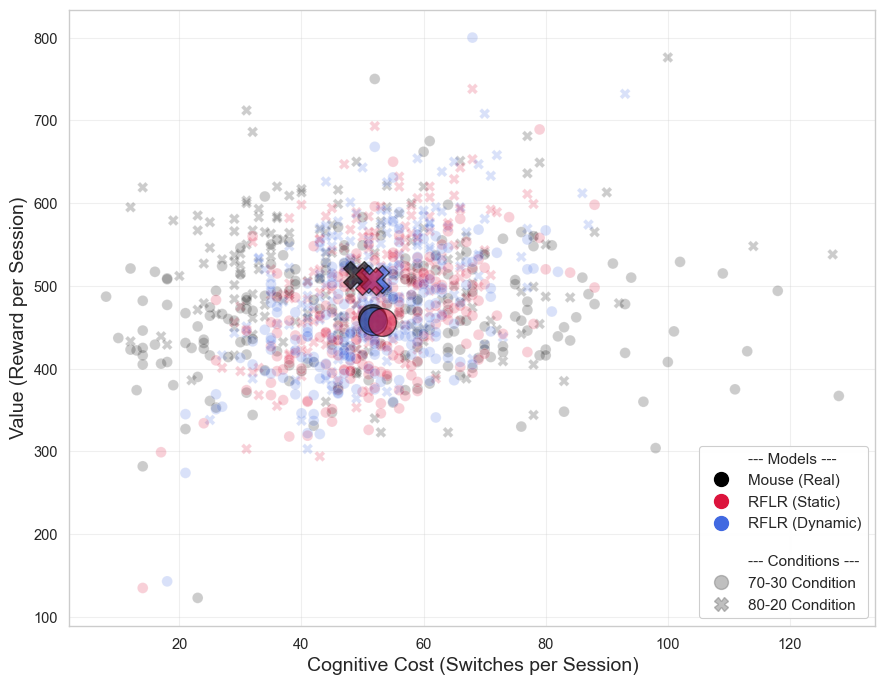

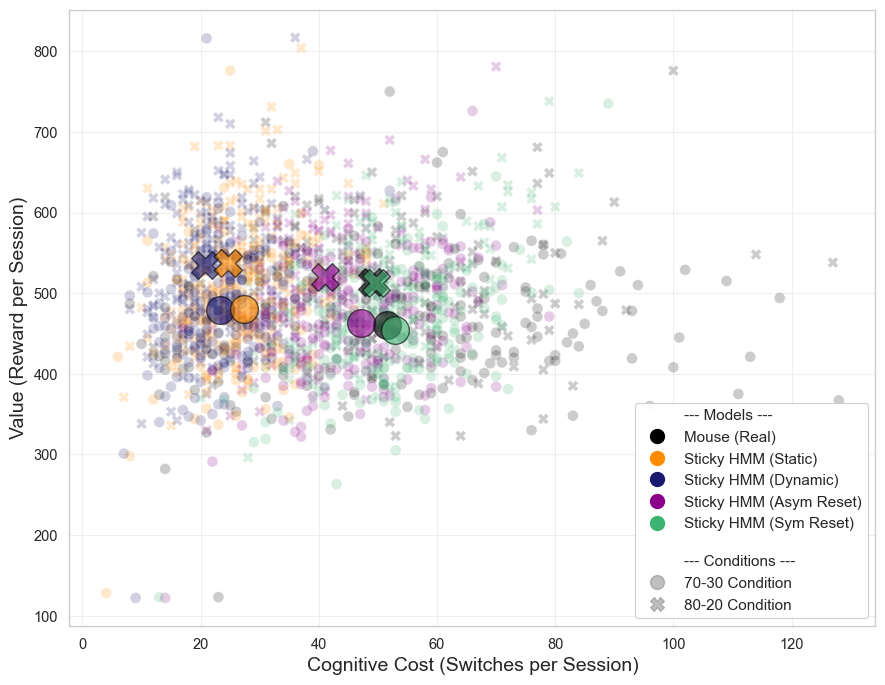

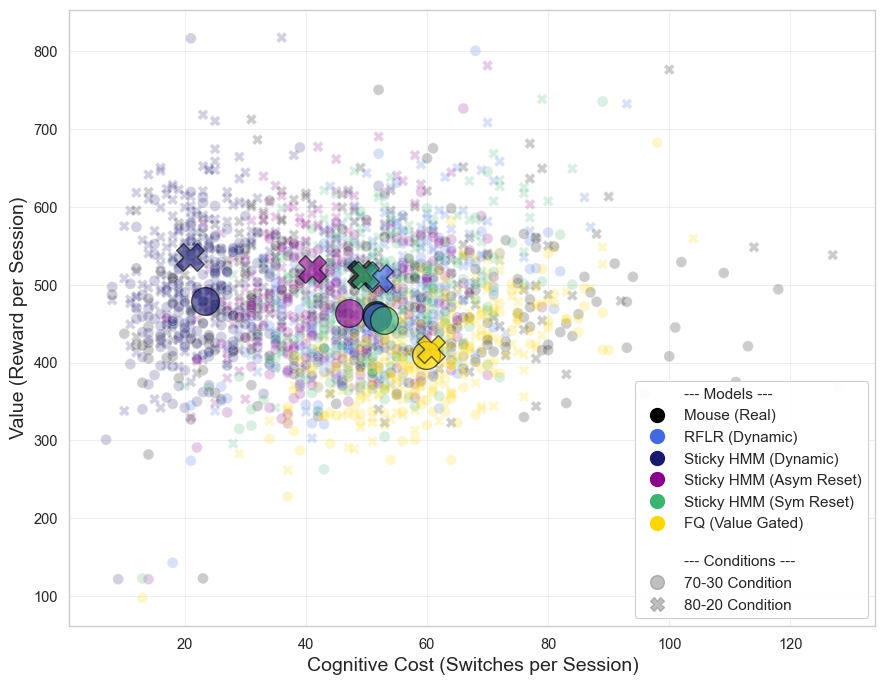

In [55]:
# 1. GENERATIVE SIMULATION FUNCTIONS (PHASE 4 CLOSED-LOOP)


def simulate_rflr_dynamic_generative(
    targets, p_reward, alpha_base, beta, tau, gamma_param, n_steps
):
    gamma_decay = np.exp(-1.0 / tau)
    res_sessions = []
    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        phi = 0
        pe_buffer = deque([0.0] * n_steps, maxlen=n_steps)

        c[0] = np.random.randint(2)
        r[0] = (
            int(np.random.rand() < p_reward)
            if c[0] == states[0]
            else int(np.random.rand() < (1 - p_reward))
        )
        prev_c_pm1 = 2 * c[0] - 1
        phi = beta * r[0] * prev_c_pm1
        pe_buffer.append(float(r[0] - 0.5))

        for t in range(1, T):
            alpha_t = alpha_base * np.exp(
                gamma_param * (sum(pe_buffer) / len(pe_buffer))
            )
            psi = phi + alpha_t * prev_c_pm1
            c[t] = int(np.random.rand() < (1.0 / (1.0 + np.exp(-psi))))
            r[t] = (
                int(np.random.rand() < p_reward)
                if c[t] == states[t]
                else int(np.random.rand() < (1 - p_reward))
            )

            curr_c_pm1 = 2 * c[t] - 1
            expected_r = 1.0 / (1.0 + np.exp(-(phi * curr_c_pm1)))
            pe_buffer.append(float(r[t] - expected_r))
            phi = phi * gamma_decay + beta * r[t] * curr_c_pm1
            prev_c_pm1 = curr_c_pm1
        res_sessions.append((c, r))
    return res_sessions


def simulate_hmm_sticky_dynamic_generative(
    targets, p_reward, p_switch, alpha_base, beta, tau_val, gamma_param, n_steps
):
    decay = float(np.exp(-1.0 / tau_val))
    res_sessions = []

    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        belief = 0.5
        pe_buffer = deque([0.0] * n_steps, maxlen=n_steps)

        stickiness = np.zeros(T, dtype=float)
        agent_choices_pm1 = np.zeros(T)

        c[0] = np.random.randint(2)
        r[0] = (
            int(np.random.rand() < p_reward)
            if c[0] == states[0]
            else int(np.random.rand() < (1 - p_reward))
        )
        agent_choices_pm1[0] = 2 * c[0] - 1
        pe_buffer.append(float(r[0] - 0.5))

        for t in range(1, T):
            belief = belief * (1 - p_switch) + (1 - belief) * p_switch

            alpha_t = alpha_base * np.exp(
                gamma_param * (sum(pe_buffer) / len(pe_buffer))
            )

            if t == 1:
                stickiness[t] = (alpha_t + beta / 2.0) * agent_choices_pm1[0]
            elif t > 1:
                s1 = alpha_t + beta / 2.0
                s2 = -alpha_t * decay
                stickiness[t] = (
                    decay * stickiness[t - 1]
                    + s1 * agent_choices_pm1[t - 1]
                    + s2 * agent_choices_pm1[t - 2]
                )

            belief_clipped = max(min(belief, 1 - 1e-8), 1e-8)
            log_odds = np.log(belief_clipped / (1.0 - belief_clipped))
            psi = log_odds + stickiness[t]

            c[t] = int(np.random.rand() < (1.0 / (1.0 + np.exp(-psi))))
            agent_choices_pm1[t] = 2 * c[t] - 1

            r[t] = (
                int(np.random.rand() < p_reward)
                if c[t] == states[t]
                else int(np.random.rand() < (1 - p_reward))
            )
            expected_r = (
                belief * p_reward + (1 - belief) * (1 - p_reward)
                if c[t] == 1
                else (1 - belief) * p_reward + belief * (1 - p_reward)
            )
            pe_buffer.append(float(r[t] - expected_r))

            lik_1 = (
                p_reward
                if (c[t] == 1 and r[t] == 1) or (c[t] == 0 and r[t] == 0)
                else (1 - p_reward)
            )
            lik_0 = (
                p_reward
                if (c[t] == 0 and r[t] == 1) or (c[t] == 1 and r[t] == 0)
                else (1 - p_reward)
            )
            unnorm_1, unnorm_0 = belief * lik_1, (1 - belief) * lik_0
            belief = unnorm_1 / (unnorm_1 + unnorm_0)

        res_sessions.append((c, r))
    return res_sessions


def simulate_hmm_reset_generative(
    targets, p_reward, p_switch, alpha_base, beta, tau_val, gamma_param, n_steps
):
    decay = float(np.exp(-1.0 / tau_val))
    res_sessions = []

    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        belief = 0.5
        pe_buffer = deque([0.0] * n_steps, maxlen=n_steps)

        stickiness = np.zeros(T, dtype=float)
        agent_choices_pm1 = np.zeros(T)

        c[0] = np.random.randint(2)
        r[0] = (
            int(np.random.rand() < p_reward)
            if c[0] == states[0]
            else int(np.random.rand() < (1 - p_reward))
        )
        agent_choices_pm1[0] = 2 * c[0] - 1
        pe_buffer.append(float(r[0] - 0.5))

        for t in range(1, T):
            # 1. Prior
            belief = belief * (1 - p_switch) + (1 - belief) * p_switch

            avg_pe = sum(pe_buffer) / len(pe_buffer)
            alpha_t = alpha_base * np.exp(gamma_param * avg_pe)

            negative_surprise = min(0.0, avg_pe)  # Asymmetric
            reset_strength = 1.0 - np.exp(gamma_param * negative_surprise)

            if t == 1:
                stickiness[t] = (alpha_t + beta / 2.0) * agent_choices_pm1[0]
            elif t > 1:
                s1 = alpha_t + beta / 2.0
                s2 = -alpha_t * decay
                stickiness[t] = (
                    decay * stickiness[t - 1]
                    + s1 * agent_choices_pm1[t - 1]
                    + s2 * agent_choices_pm1[t - 2]
                )

            belief_clipped = max(min(belief, 1 - 1e-8), 1e-8)
            log_odds = np.log(belief_clipped / (1.0 - belief_clipped))
            psi = log_odds + stickiness[t]

            c[t] = int(np.random.rand() < (1.0 / (1.0 + np.exp(-psi))))
            agent_choices_pm1[t] = 2 * c[t] - 1

            r[t] = (
                int(np.random.rand() < p_reward)
                if c[t] == states[t]
                else int(np.random.rand() < (1 - p_reward))
            )
            expected_r = (
                belief * p_reward + (1 - belief) * (1 - p_reward)
                if c[t] == 1
                else (1 - belief) * p_reward + belief * (1 - p_reward)
            )
            pe_buffer.append(float(r[t] - expected_r))

            lik_1 = (
                p_reward
                if (c[t] == 1 and r[t] == 1) or (c[t] == 0 and r[t] == 0)
                else (1 - p_reward)
            )
            lik_0 = (
                p_reward
                if (c[t] == 0 and r[t] == 1) or (c[t] == 1 and r[t] == 0)
                else (1 - p_reward)
            )
            belief_raw = (belief * lik_1) / ((belief * lik_1) + ((1 - belief) * lik_0))

            belief = belief_raw * (1 - reset_strength) + 0.5 * reset_strength

        res_sessions.append((c, r))
    return res_sessions


def simulate_hmm_reset_v2_generative(
    targets, p_reward, p_switch, alpha_base, beta, tau_val, gamma_param, n_steps
):
    decay = float(np.exp(-1.0 / tau_val))
    res_sessions = []

    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        belief = 0.5
        pe_buffer = deque([0.0] * n_steps, maxlen=n_steps)

        stickiness = np.zeros(T, dtype=float)
        agent_choices_pm1 = np.zeros(T)

        c[0] = np.random.randint(2)
        r[0] = (
            int(np.random.rand() < p_reward)
            if c[0] == states[0]
            else int(np.random.rand() < (1 - p_reward))
        )
        agent_choices_pm1[0] = 2 * c[0] - 1
        pe_buffer.append(float(r[0] - 0.5))

        for t in range(1, T):
            # 1. Prior
            belief = belief * (1 - p_switch) + (1 - belief) * p_switch

            avg_pe = sum(pe_buffer) / len(pe_buffer)
            alpha_t = alpha_base * np.exp(gamma_param * avg_pe)

            reset_strength = 1.0 - np.exp(-abs(gamma_param) * abs(avg_pe))  # Symmetric

            if t == 1:
                stickiness[t] = (alpha_t + beta / 2.0) * agent_choices_pm1[0]
            elif t > 1:
                s1 = alpha_t + beta / 2.0
                s2 = -alpha_t * decay
                stickiness[t] = (
                    decay * stickiness[t - 1]
                    + s1 * agent_choices_pm1[t - 1]
                    + s2 * agent_choices_pm1[t - 2]
                )

            belief_clipped = max(min(belief, 1 - 1e-8), 1e-8)
            log_odds = np.log(belief_clipped / (1.0 - belief_clipped))
            psi = log_odds + stickiness[t]

            c[t] = int(np.random.rand() < (1.0 / (1.0 + np.exp(-psi))))
            agent_choices_pm1[t] = 2 * c[t] - 1

            r[t] = (
                int(np.random.rand() < p_reward)
                if c[t] == states[t]
                else int(np.random.rand() < (1 - p_reward))
            )
            expected_r = (
                belief * p_reward + (1 - belief) * (1 - p_reward)
                if c[t] == 1
                else (1 - belief) * p_reward + belief * (1 - p_reward)
            )
            pe_buffer.append(float(r[t] - expected_r))

            lik_1 = (
                p_reward
                if (c[t] == 1 and r[t] == 1) or (c[t] == 0 and r[t] == 0)
                else (1 - p_reward)
            )
            lik_0 = (
                p_reward
                if (c[t] == 0 and r[t] == 1) or (c[t] == 1 and r[t] == 0)
                else (1 - p_reward)
            )
            belief_raw = (belief * lik_1) / ((belief * lik_1) + ((1 - belief) * lik_0))

            belief = belief_raw * (1 - reset_strength) + 0.5 * reset_strength

        res_sessions.append((c, r))
    return res_sessions


def simulate_fq_value_gated_generative(
    targets, p_reward, alpha_base, tau_val, n_steps, temp=1.0
):
    k_lr = 1.0 - np.exp(-1.0 / tau_val)
    res_sessions = []
    for states in targets:
        T = len(states)
        c, r = np.zeros(T, dtype=int), np.zeros(T, dtype=int)
        q_curr = np.array([0.5, 0.5], dtype=float)
        window_choices, window_rewards = [], []

        c[0] = np.random.randint(2)
        r[0] = (
            int(np.random.rand() < p_reward)
            if c[0] == states[0]
            else int(np.random.rand() < (1 - p_reward))
        )
        window_choices.append(c[0])
        window_rewards.append(r[0])
        prev_c_pm1 = 2 * c[0] - 1

        for t in range(1, T):
            psi = ((q_curr[1] - q_curr[0]) / max(temp, 1e-8)) + alpha_base * prev_c_pm1
            c[t] = int(np.random.rand() < (1.0 / (1.0 + np.exp(-psi))))
            r[t] = (
                int(np.random.rand() < p_reward)
                if c[t] == states[t]
                else int(np.random.rand() < (1 - p_reward))
            )

            window_choices.append(c[t])
            window_rewards.append(r[t])

            if len(window_rewards) == n_steps or t == T - 1:
                q_next = q_curr.copy()
                window_choices_arr = np.array(window_choices)
                window_rewards_arr = np.array(window_rewards, dtype=float)
                for arm in (0, 1):
                    mask = window_choices_arr == arm
                    if np.any(mask):
                        reward_mean = float(np.mean(window_rewards_arr[mask]))
                        q_next[arm] = q_curr[arm] + k_lr * (reward_mean - q_curr[arm])
                    else:
                        q_next[arm] = (1.0 - k_lr) * q_curr[arm]
                q_curr = np.clip(q_next, 0.0, 1.0)
                window_choices, window_rewards = [], []

            prev_c_pm1 = 2 * c[t] - 1
        res_sessions.append((c, r))
    return res_sessions


# 2. DATA AGGREGATION LOOP

np.random.seed(12)
simulated_data = []

for condition in ["80-20", "70-30"]:
    sessions, targets = extract_sessions(df, condition)
    p_high = int(condition.split("-")[0]) / 100.0

    beta_val = df_cv[df_cv["Condition"] == condition]["Beta"].mean()
    tau_val = df_cv[df_cv["Condition"] == condition]["Tau"].mean()
    alpha_static = df_cv[df_cv["Condition"] == condition]["Alpha"].mean()
    est_p_switch = 1.0 / np.mean([len(t) / np.sum(np.abs(np.diff(t))) for t in targets])

    def record(sess_list, label):
        for c, r in sess_list:
            simulated_data.append(
                {
                    "Condition": condition,
                    "Model": label,
                    "Switches": np.sum(np.abs(np.diff(c))),
                    "Reward": np.sum(r),
                }
            )

    record(sessions, "Mouse (Real)")

    r_static, s_static, _ = simulate_agents(
        targets, p_high, est_p_switch, alpha_static, beta_val, tau_val
    )
    record(r_static, "RFLR (Static)")
    record(s_static, "Sticky HMM (Static)")

    p = df_p4[(df_p4["Condition"] == condition) & (df_p4["Model"] == "RFLR")].iloc[0]
    rflr_dyn = simulate_rflr_dynamic_generative(
        targets,
        p_high,
        p["Alpha_base"],
        beta_val,
        tau_val,
        p["Gamma"],
        int(p["N_steps"]),
    )
    record(rflr_dyn, "RFLR (Dynamic)")

    p = df_p4[
        (df_p4["Condition"] == condition) & (df_p4["Model"] == "HMM_sticky")
    ].iloc[0]
    hmm_dyn = simulate_hmm_sticky_dynamic_generative(
        targets,
        p_high,
        est_p_switch,
        p["Alpha_base"],
        beta_val,
        tau_val,
        p["Gamma"],
        int(p["N_steps"]),
    )
    record(hmm_dyn, "Sticky HMM (Dynamic)")

    p = df_p4[(df_p4["Condition"] == condition) & (df_p4["Model"] == "HMM_reset")].iloc[
        0
    ]
    hmm_reset = simulate_hmm_reset_generative(
        targets,
        p_high,
        est_p_switch,
        p["Alpha_base"],
        beta_val,
        tau_val,
        p["Gamma"],
        int(p["N_steps"]),
    )
    record(hmm_reset, "Sticky HMM (Asym Reset)")

    p = df_p4[
        (df_p4["Condition"] == condition) & (df_p4["Model"] == "HMM_resetv2")
    ].iloc[0]
    hmm_resetv2 = simulate_hmm_reset_v2_generative(
        targets,
        p_high,
        est_p_switch,
        p["Alpha_base"],
        beta_val,
        tau_val,
        p["Gamma"],
        int(p["N_steps"]),
    )
    record(hmm_resetv2, "Sticky HMM (Sym Reset)")

    p = df_p4[
        (df_p4["Condition"] == condition) & (df_p4["Model"] == "FQ_Value_Gated")
    ].iloc[0]
    fq_val = simulate_fq_value_gated_generative(
        targets, p_high, p["Alpha_base"], tau_val, int(p["N_steps"])
    )
    record(fq_val, "FQ (Value Gated)")

df_simulated = pd.DataFrame(simulated_data)


# 3. INDIVIDUAL PLOTTING SCRIPT (3 Separate Figures)

# Redesigned, elegant color palette
model_colors = {
    "Mouse (Real)": "black",
    "RFLR (Static)": "crimson",
    "Sticky HMM (Static)": "darkorange",
    "RFLR (Dynamic)": "royalblue",
    "Sticky HMM (Dynamic)": "midnightblue",
    "Sticky HMM (Asym Reset)": "darkmagenta",
    "Sticky HMM (Sym Reset)": "mediumseagreen",
    "FQ (Value Gated)": "gold",
}

condition_markers = {"70-30": "o", "80-20": "X"}

comparisons = [
    {
        "title": "Reward_vs_Cognitive_Cost: RFLR Static vs Dynamic",
        "models": ["Mouse (Real)", "RFLR (Static)", "RFLR (Dynamic)"],
    },
    {
        "title": "Reward_vs_Cognitive_Cost: HMM models comparison",
        "models": [
            "Mouse (Real)",
            "Sticky HMM (Static)",
            "Sticky HMM (Dynamic)",
            "Sticky HMM (Asym Reset)",
            "Sticky HMM (Sym Reset)",
        ],
    },
    {
        "title": "Reward_vs_Cognitive_Cost: dynamic models comparison",
        "models": [
            "Mouse (Real)",
            "RFLR (Dynamic)",
            "Sticky HMM (Dynamic)",
            "Sticky HMM (Asym Reset)",
            "Sticky HMM (Sym Reset)",
            "FQ (Value Gated)",
        ],
    },
]

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

for comp in comparisons:
    fig, ax = plt.subplots(figsize=(9, 7))  # Creates a new individual plot
    df_plot = df_simulated[df_simulated["Model"].isin(comp["models"])]

    # Background individual session points
    sns.scatterplot(
        data=df_plot,
        x="Switches",
        y="Reward",
        hue="Model",
        style="Condition",
        palette=model_colors,
        markers=condition_markers,
        alpha=0.2,
        s=60,
        ax=ax,
        legend=False,
    )

    # Emphasized Centroids
    centroids = (
        df_plot.groupby(["Condition", "Model"])[["Switches", "Reward"]]
        .mean()
        .reset_index()
    )
    for _, row in centroids.iterrows():
        ax.scatter(
            row["Switches"],
            row["Reward"],
            s=400,
            color=model_colors[row["Model"]],
            marker=condition_markers[row["Condition"]],
            linewidth=1,
            zorder=10,
            alpha=0.6,
            edgecolors="black",
        )

    ax.set_xlabel("Cognitive Cost (Switches per Session)", fontsize=14)
    ax.set_ylabel("Value (Reward per Session)", fontsize=14)
    ax.grid(True, alpha=0.3)

    # Isolated Legend
    legend_elements = [mlines.Line2D([], [], color="none", label="--- Models ---")]
    for model in comp["models"]:
        legend_elements.append(
            mlines.Line2D(
                [],
                [],
                color=model_colors[model],
                marker="o",
                linestyle="None",
                markersize=10,
                label=model,
            )
        )

    legend_elements.append(
        mlines.Line2D([], [], color="none", label="\n--- Conditions ---")
    )
    legend_elements.append(
        mlines.Line2D(
            [],
            [],
            color="gray",
            marker="o",
            linestyle="None",
            markersize=10,
            label="70-30 Condition",
            alpha=0.5,
        )
    )
    legend_elements.append(
        mlines.Line2D(
            [],
            [],
            color="gray",
            marker="X",
            linestyle="None",
            markersize=10,
            label="80-20 Condition",
            alpha=0.5,
        )
    )

    ax.legend(handles=legend_elements, loc="lower right", framealpha=0.95, fontsize=11)

    plt.tight_layout()
    safe_filename = comp["title"].replace(" ", "_").replace(":", "") + ".pdf"
    save_path = os.path.join(fig_dir, safe_filename)

    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()  # Displays the individual figure


--- Processing Condition: 80-20 ---


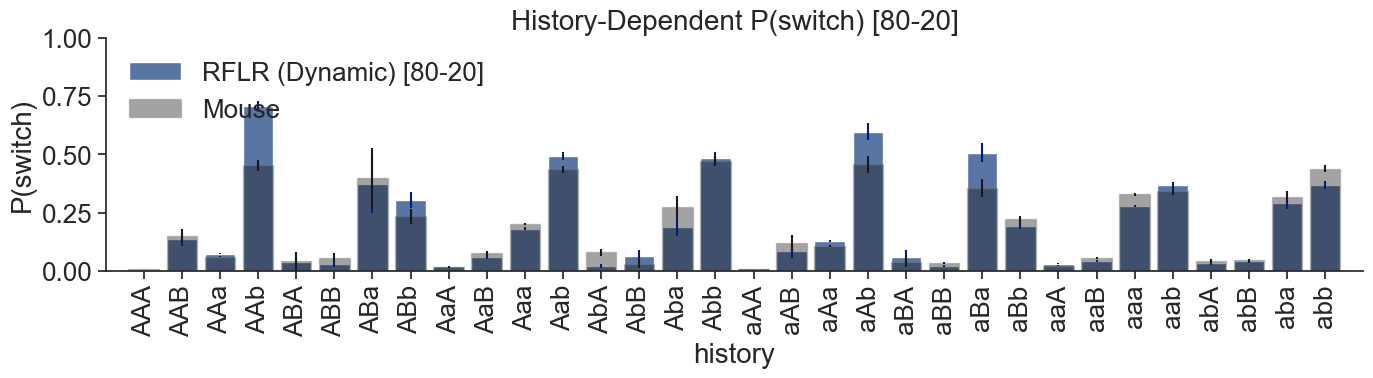


--- Processing Condition: 70-30 ---


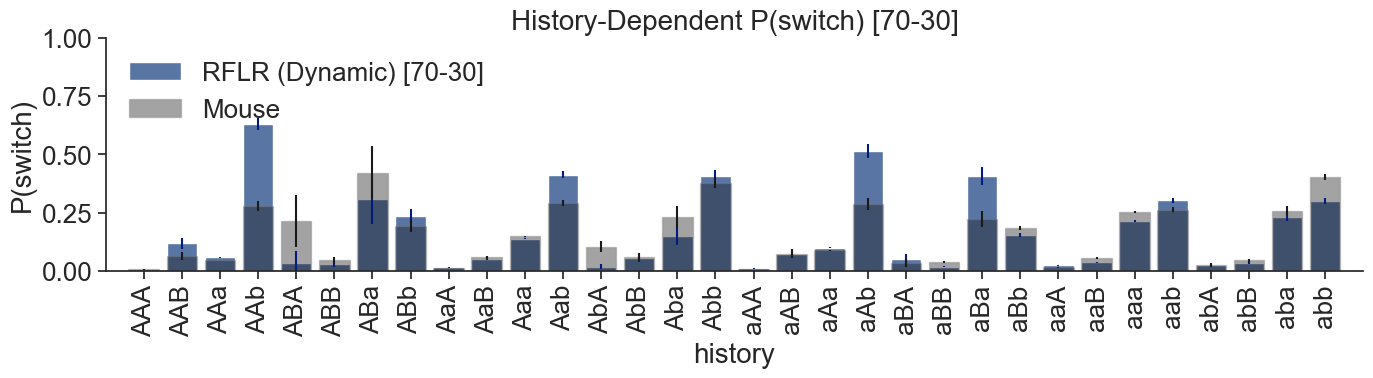


--- Generating Combined Plots ---


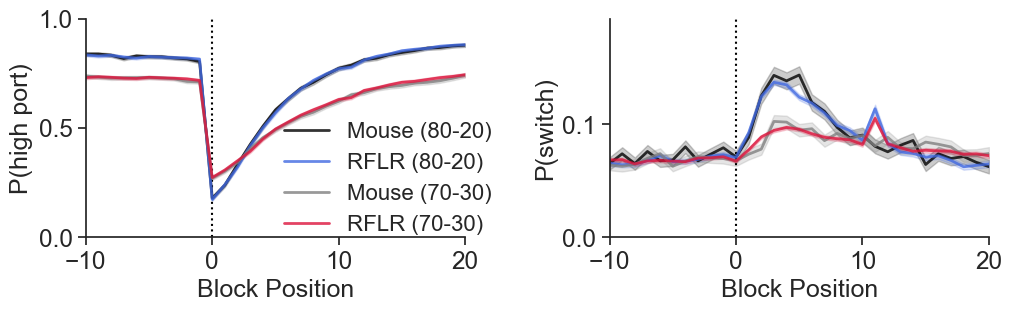

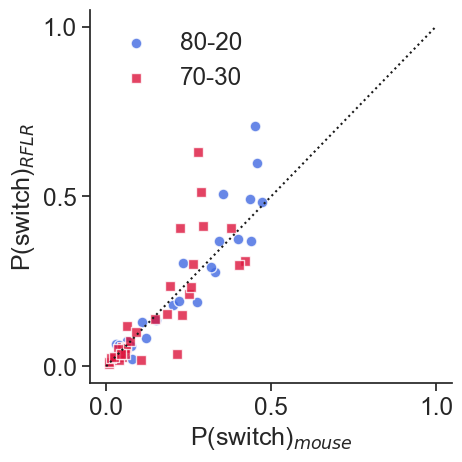

In [48]:
# Containers to accumulate data for the combined plots
all_bpos = []
hist_data = {}


# LOOP THROUGH CONDITIONS

for condition_to_plot in ["80-20", "70-30"]:
    print(f"\n--- Processing Condition: {condition_to_plot} ---")

    # 1. Prepare Data & Strict Alignment
    df_mouse = df[df["Condition"] == condition_to_plot].copy()

    # Preprocessing required by the original repo's plotting functions
    df_mouse["block_pos_rev"] = df_mouse["blockTrial"] - df_mouse["blockLength"]
    df_mouse["highPort"] = (df_mouse["Decision"] == df_mouse["Target"]).astype(int)

    # Extract RFLR (Dynamic) Optimal Parameters
    beta_val = df_cv[df_cv["Condition"] == condition_to_plot]["Beta"].mean()
    tau_val = df_cv[df_cv["Condition"] == condition_to_plot]["Tau"].mean()
    p_dyn = df_p4[
        (df_p4["Condition"] == condition_to_plot) & (df_p4["Model"] == "RFLR")
    ].iloc[0]

    # Extract sessions STRICTLY matching the DataFrame order
    session_list = df_mouse["Session"].unique()
    strict_sessions = []
    for sess in session_list:
        sess_df = df_mouse[(df_mouse["Session"] == sess) & df_mouse["Decision"].notna()]
        c = sess_df["Decision"].astype(int).values
        r = sess_df["Reward"].astype(int).values
        strict_sessions.append((c, r))

    # 2. Generate Predictive Policies
    res = run_rflr_nonlinear_stickiness(
        strict_sessions,
        (p_dyn["Alpha_base"], beta_val, tau_val),
        int(p_dyn["N_steps"]),
        p_dyn["Gamma"],
        fit_mode=True,
    )
    policies = res["policies"]

    # 3. Map Probabilities (100% Guaranteed Alignment)
    df_model = df_mouse.copy()
    df_model["p_right"] = np.nan

    policy_idx = 0
    for sess in session_list:
        sess_mask = (df_model["Session"] == sess) & df_model["Decision"].notna()
        valid_row_indices = df_model[sess_mask].index
        df_model.loc[valid_row_indices, "p_right"] = policies[policy_idx][:, 1]
        policy_idx += 1

    # Drop any unmapped/invalid trials
    df_model = df_model.dropna(subset=["p_right"]).copy()
    df_mouse = df_mouse.loc[df_model.index].copy()

    # Calculate Expectations
    p_right_safe = df_model["p_right"].values
    p_left_safe = 1.0 - p_right_safe
    target_port = df_model["Target"].values
    df_model["highPort"] = np.where(target_port == 1, p_right_safe, p_left_safe)

    prev_choice = df_model["Decision"].shift(1).fillna(0).values
    df_model["Switch"] = np.where(prev_choice == 1, p_left_safe, p_right_safe)

    # 4. Save Plot 1 Data for Later Merging
    bpos_mouse = pmm.get_block_position_summaries(df_mouse)
    bpos_mouse["Group"] = f"Mouse ({condition_to_plot})"
    bpos_model = pmm.get_block_position_summaries(df_model)
    bpos_model["Group"] = f"RFLR ({condition_to_plot})"
    all_bpos.extend([bpos_mouse, bpos_model])

    # 5. Process History Data
    df_mouse_hist = cp.add_history_cols(df_mouse, N=3)
    df_model_hist = cp.add_history_cols(df_model, N=3)

    df_hist_mouse = cp.calc_conditional_probs(
        df_mouse_hist, symm=True, action=["Switch"]
    )
    df_hist_model = cp.calc_conditional_probs(
        df_model_hist, symm=True, action=["Switch"]
    )

    # Align model sequences to match mouse data
    df_hist_model = cp.sort_cprobs(df_hist_model, df_hist_mouse["history"].tolist())

    # Store for combined Plot 3
    hist_data[condition_to_plot] = (df_hist_mouse, df_hist_model)

    # PLOT 2: Separate per condition

    model_color = sns.color_palette()[0]  # Default blue for pmm plotting

    pmm.plot_sequences(
        df=df_hist_mouse,
        overlay=df_hist_model,
        main_label="Mouse",
        overlay_label=f"RFLR (Dynamic) [{condition_to_plot}]",
        title=f"History-Dependent P(switch) [{condition_to_plot}]",
    )
    plt.savefig(
        os.path.join(
            fig_dir, f"History-Dependent P(switch)_RFLR_[{condition_to_plot}].pdf"
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


# COMBINED PLOTS (Outside the loop)

print("\n--- Generating Combined Plots ---")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- Plot 1: Combined Transition Dynamics ---
bpos_combined = pd.concat(all_bpos, ignore_index=True)


color_dict_transitions_RFLR = {
    "Mouse (80-20)": "black",
    "RFLR (80-20)": "royalblue",
    "Mouse (70-30)": "gray",
    "RFLR (70-30)": "crimson",
}

pmm.plot_by_block_position(
    bpos_combined, subset="Group", color_dict=color_dict_transitions_RFLR
)
plt.savefig(
    os.path.join(fig_dir, "Transition Dynamics: RFLR (Dynamic) [80-20 & 70-30].pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()


# --- Plot 3: Combined P(switch) Scatter Correlation ---
# We manually construct this scatter to support dual-coloring on the exact same axes
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], ":k")  # Diagonal reference line

# Plot 80-20 (Blue)
df_m_80, df_mdl_80 = hist_data["80-20"]
plt.scatter(
    df_m_80["pswitch"],
    df_mdl_80["pswitch"],
    color="royalblue",
    label="80-20",
    alpha=0.8,
    s=60,
    edgecolor="white",
)

# Plot 70-30 (Red)
df_m_70, df_mdl_70 = hist_data["70-30"]
plt.scatter(
    df_m_70["pswitch"],
    df_mdl_70["pswitch"],
    color="crimson",
    label="70-30",
    alpha=0.8,
    s=60,
    marker="s",
    edgecolor="white",
)

plt.xlabel("P(switch)$_{mouse}$")
plt.ylabel("P(switch)$_{RFLR}$")
plt.xticks(np.arange(0, 1.1, 0.5))
plt.yticks(np.arange(0, 1.1, 0.5))
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "P(switch) Correlation: Mouse vs RFLR (Dynamic).pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()


--- Processing Condition: 80-20 ---


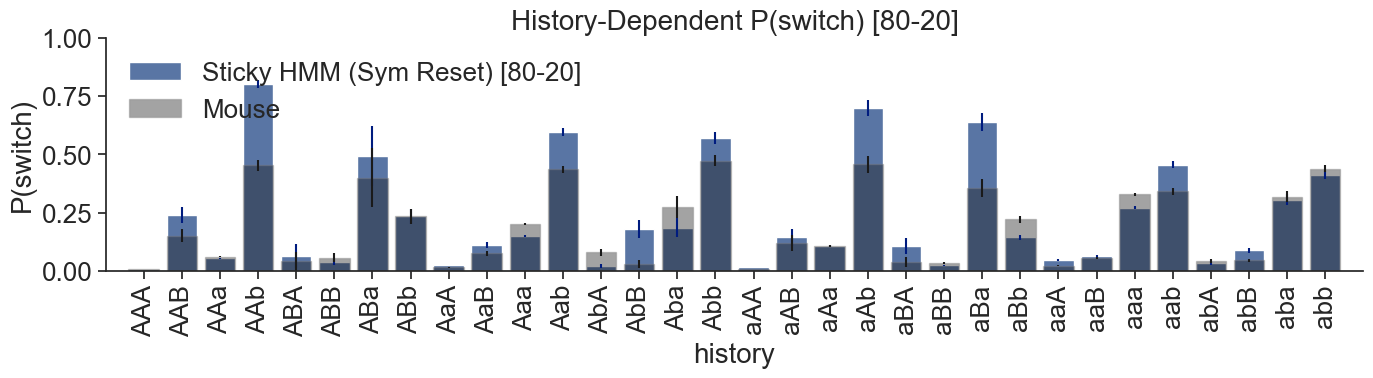


--- Processing Condition: 70-30 ---


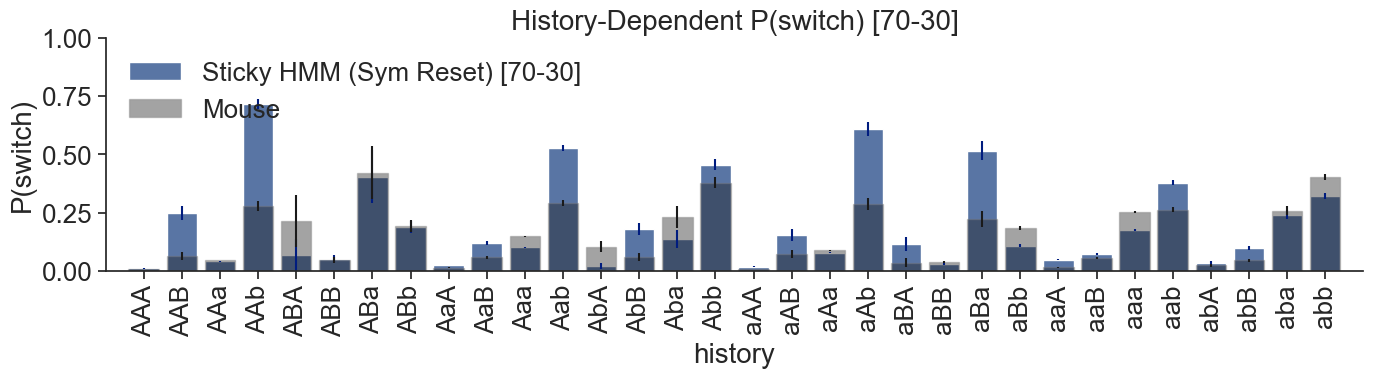


--- Generating Combined Plots (Sticky HMM) ---


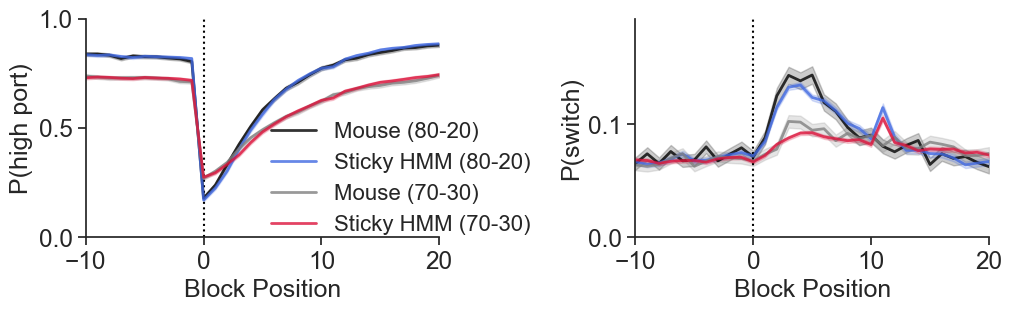

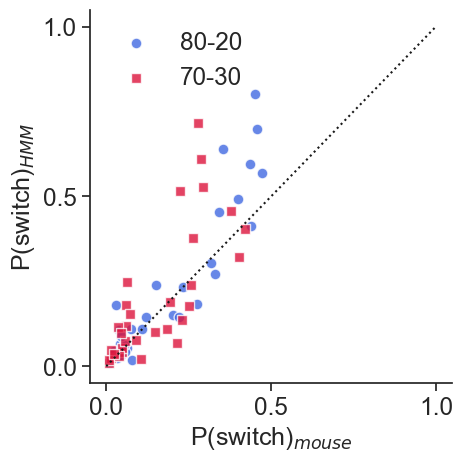

In [49]:
# Containers to accumulate data for the combined plots
all_bpos_hmm = []
hist_data_hmm = {}


# LOOP THROUGH CONDITIONS

for condition_to_plot in ["80-20", "70-30"]:
    print(f"\n--- Processing Condition: {condition_to_plot} ---")

    # 1. Prepare Data & Strict Alignment
    df_mouse = df[df["Condition"] == condition_to_plot].copy()

    # Preprocessing required by the original repo's plotting functions
    df_mouse["block_pos_rev"] = df_mouse["blockTrial"] - df_mouse["blockLength"]
    df_mouse["highPort"] = (df_mouse["Decision"] == df_mouse["Target"]).astype(int)

    # Extract Sticky HMM (Sym Reset) Optimal Parameters
    beta_val = df_cv[df_cv["Condition"] == condition_to_plot]["Beta"].mean()
    tau_val = df_cv[df_cv["Condition"] == condition_to_plot]["Tau"].mean()
    p_dyn = df_p4[
        (df_p4["Condition"] == condition_to_plot) & (df_p4["Model"] == "HMM_resetv2")
    ].iloc[0]

    # Extract sessions STRICTLY matching the DataFrame order
    session_list = df_mouse["Session"].unique()
    strict_sessions = []
    strict_targets = []
    for sess in session_list:
        sess_df = df_mouse[(df_mouse["Session"] == sess) & df_mouse["Decision"].notna()]
        c = sess_df["Decision"].astype(int).values
        r = sess_df["Reward"].astype(int).values
        strict_sessions.append((c, r))
        strict_targets.append(sess_df["Target"].astype(int).values)

    # 2. Generate Predictive Policies (HMM Specific)
    hmm_params = {
        "q": 1.0
        - (
            1.0 / np.mean([len(t) / np.sum(np.abs(np.diff(t))) for t in strict_targets])
        ),
        "p": int(condition_to_plot.split("-")[0]) / 100.0,
        "alpha": p_dyn["Alpha_base"],
        "beta": beta_val,
        "tau": tau_val,
    }

    res = run_hmm_resetv2_nonlinear_stickiness(
        strict_sessions,
        hmm_params,
        int(p_dyn["N_steps"]),
        p_dyn["Gamma"],
        fit_mode=True,
    )
    policies = res["policies"]

    # 3. Map Probabilities (100% Guaranteed Alignment)
    df_model = df_mouse.copy()
    df_model["p_right"] = np.nan

    policy_idx = 0
    for sess in session_list:
        sess_mask = (df_model["Session"] == sess) & df_model["Decision"].notna()
        valid_row_indices = df_model[sess_mask].index
        df_model.loc[valid_row_indices, "p_right"] = policies[policy_idx][:, 1]
        policy_idx += 1

    # Drop any unmapped/invalid trials
    df_model = df_model.dropna(subset=["p_right"]).copy()
    df_mouse = df_mouse.loc[df_model.index].copy()

    # Calculate Expectations
    p_right_safe = df_model["p_right"].values
    p_left_safe = 1.0 - p_right_safe
    target_port = df_model["Target"].values
    df_model["highPort"] = np.where(target_port == 1, p_right_safe, p_left_safe)

    prev_choice = df_model["Decision"].shift(1).fillna(0).values
    df_model["Switch"] = np.where(prev_choice == 1, p_left_safe, p_right_safe)

    # 4. Save Plot 1 Data for Later Merging
    bpos_mouse = pmm.get_block_position_summaries(df_mouse)
    bpos_mouse["Group"] = f"Mouse ({condition_to_plot})"
    bpos_model = pmm.get_block_position_summaries(df_model)
    bpos_model["Group"] = f"Sticky HMM ({condition_to_plot})"
    all_bpos_hmm.extend([bpos_mouse, bpos_model])

    # 5. Process History Data
    df_mouse_hist = cp.add_history_cols(df_mouse, N=3)
    df_model_hist = cp.add_history_cols(df_model, N=3)

    df_hist_mouse = cp.calc_conditional_probs(
        df_mouse_hist, symm=True, action=["Switch"]
    )
    df_hist_model = cp.calc_conditional_probs(
        df_model_hist, symm=True, action=["Switch"]
    )

    # Align model sequences to match mouse data
    df_hist_model = cp.sort_cprobs(df_hist_model, df_hist_mouse["history"].tolist())

    # Store for combined Plot 3
    hist_data_hmm[condition_to_plot] = (df_hist_mouse, df_hist_model)

    # PLOT 2: Separate per condition

    pmm.plot_sequences(
        df=df_hist_mouse,
        overlay=df_hist_model,
        main_label="Mouse",
        overlay_label=f"Sticky HMM (Sym Reset) [{condition_to_plot}]",
        title=f"History-Dependent P(switch) [{condition_to_plot}]",
    )
    plt.savefig(
        os.path.join(
            fig_dir,
            f"History-Dependent P(switch)_Sticky HMM (Sym Reset)_[{condition_to_plot}].pdf",
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


# COMBINED PLOTS (Outside the loop)

print("\n--- Generating Combined Plots (Sticky HMM) ---")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- Plot 1: Combined Transition Dynamics ---
bpos_combined_hmm = pd.concat(all_bpos_hmm, ignore_index=True)

# Using distinctly different colors for 80-20 vs 70-30
color_dict_transitions_hmm = {
    "Mouse (80-20)": "black",
    "Sticky HMM (80-20)": "royalblue",
    "Mouse (70-30)": "gray",
    "Sticky HMM (70-30)": "crimson",
}

pmm.plot_by_block_position(
    bpos_combined_hmm, subset="Group", color_dict=color_dict_transitions_hmm
)
plt.savefig(
    os.path.join(
        fig_dir, "Transition Dynamics: Sticky HMM (Sym Reset) [80-20 & 70-30].pdf"
    ),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# --- Plot 3: Combined P(switch) Scatter Correlation ---
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], ":k")  # Diagonal reference line

# Plot 80-20
df_m_80, df_mdl_80 = hist_data_hmm["80-20"]
plt.scatter(
    df_m_80["pswitch"],
    df_mdl_80["pswitch"],
    color="royalblue",
    label="80-20",
    alpha=0.8,
    s=60,
    edgecolor="white",
)

# Plot 70-30
df_m_70, df_mdl_70 = hist_data_hmm["70-30"]
plt.scatter(
    df_m_70["pswitch"],
    df_mdl_70["pswitch"],
    color="crimson",
    label="70-30",
    alpha=0.8,
    s=60,
    marker="s",
    edgecolor="white",
)

plt.xlabel("P(switch)$_{mouse}$")
plt.ylabel("P(switch)$_{HMM}$")
plt.xticks(np.arange(0, 1.1, 0.5))
plt.yticks(np.arange(0, 1.1, 0.5))
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "P(switch) Correlation: Mouse vs Sticky HMM (Sym Reset).pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()


--- Processing Condition: 80-20 ---


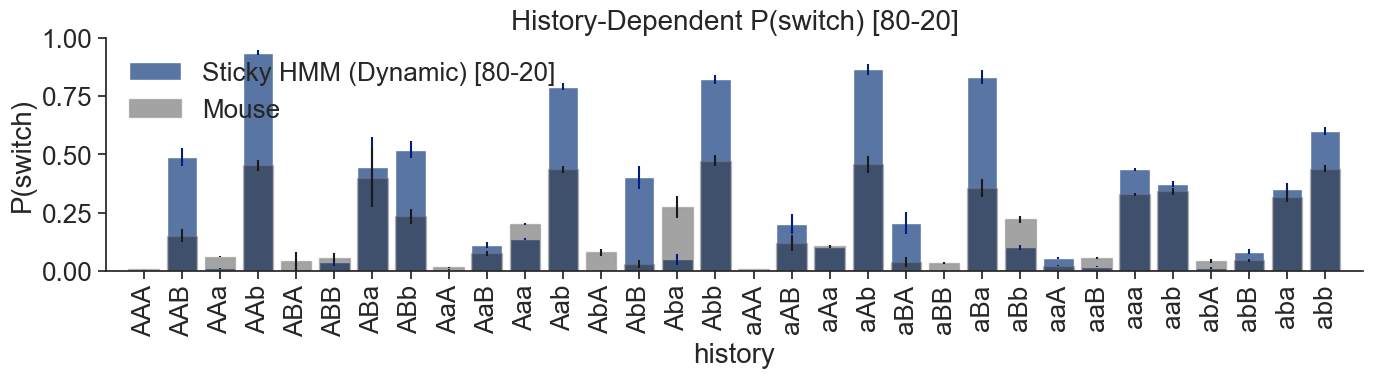


--- Processing Condition: 70-30 ---


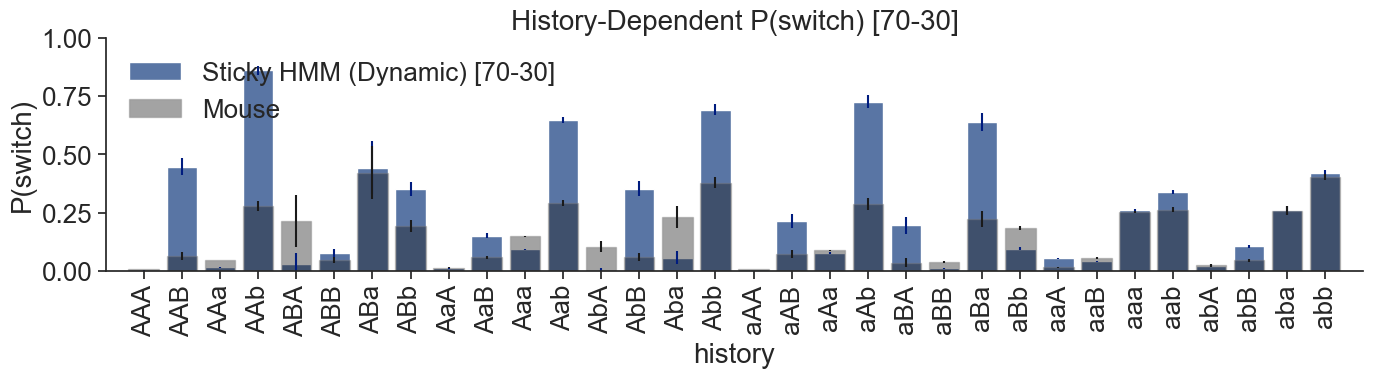


--- Generating Combined Plots (Sticky HMM) ---


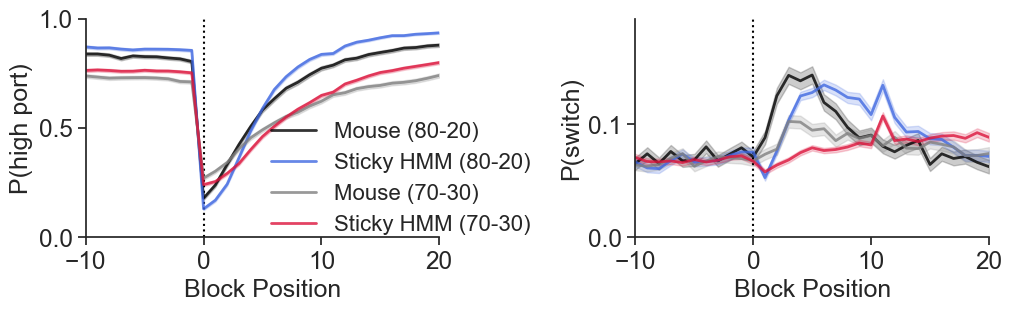

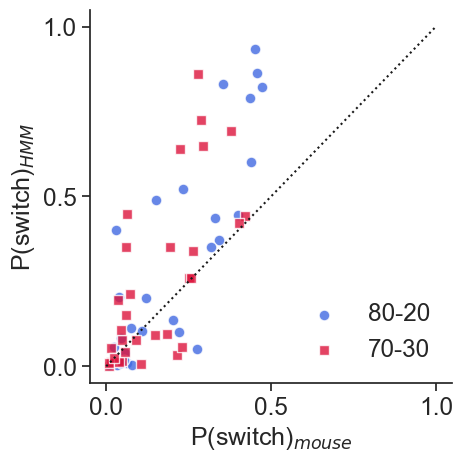

In [50]:
# Containers to accumulate data for the combined plots
all_bpos_hmm = []
hist_data_hmm = {}


# LOOP THROUGH CONDITIONS

for condition_to_plot in ["80-20", "70-30"]:
    print(f"\n--- Processing Condition: {condition_to_plot} ---")

    # 1. Prepare Data & Strict Alignment
    df_mouse = df[df["Condition"] == condition_to_plot].copy()

    # Preprocessing required by the original repo's plotting functions
    df_mouse["block_pos_rev"] = df_mouse["blockTrial"] - df_mouse["blockLength"]
    df_mouse["highPort"] = (df_mouse["Decision"] == df_mouse["Target"]).astype(int)

    # Extract Sticky HMM (Dynamic) Optimal Parameters
    beta_val = df_cv[df_cv["Condition"] == condition_to_plot]["Beta"].mean()
    tau_val = df_cv[df_cv["Condition"] == condition_to_plot]["Tau"].mean()
    p_dyn = df_p4[
        (df_p4["Condition"] == condition_to_plot) & (df_p4["Model"] == "HMM_sticky")
    ].iloc[0]

    # Extract sessions STRICTLY matching the DataFrame order
    session_list = df_mouse["Session"].unique()
    strict_sessions = []
    strict_targets = []
    for sess in session_list:
        sess_df = df_mouse[(df_mouse["Session"] == sess) & df_mouse["Decision"].notna()]
        c = sess_df["Decision"].astype(int).values
        r = sess_df["Reward"].astype(int).values
        strict_sessions.append((c, r))
        strict_targets.append(sess_df["Target"].astype(int).values)

    # 2. Generate Predictive Policies (HMM Specific)
    hmm_params = {
        "q": 1.0
        - (
            1.0 / np.mean([len(t) / np.sum(np.abs(np.diff(t))) for t in strict_targets])
        ),
        "p": int(condition_to_plot.split("-")[0]) / 100.0,
        "alpha": p_dyn["Alpha_base"],
        "beta": beta_val,
        "tau": tau_val,
    }

    res = run_hmm_nonlinear_stickiness(
        strict_sessions,
        hmm_params,
        int(p_dyn["N_steps"]),
        p_dyn["Gamma"],
        fit_mode=True,
    )
    policies = res["policies"]

    # 3. Map Probabilities (100% Guaranteed Alignment)
    df_model = df_mouse.copy()
    df_model["p_right"] = np.nan

    policy_idx = 0
    for sess in session_list:
        sess_mask = (df_model["Session"] == sess) & df_model["Decision"].notna()
        valid_row_indices = df_model[sess_mask].index
        df_model.loc[valid_row_indices, "p_right"] = policies[policy_idx][:, 1]
        policy_idx += 1

    # Drop any unmapped/invalid trials
    df_model = df_model.dropna(subset=["p_right"]).copy()
    df_mouse = df_mouse.loc[df_model.index].copy()

    # Calculate Expectations
    p_right_safe = df_model["p_right"].values
    p_left_safe = 1.0 - p_right_safe
    target_port = df_model["Target"].values
    df_model["highPort"] = np.where(target_port == 1, p_right_safe, p_left_safe)

    prev_choice = df_model["Decision"].shift(1).fillna(0).values
    df_model["Switch"] = np.where(prev_choice == 1, p_left_safe, p_right_safe)

    # 4. Save Plot 1 Data for Later Merging
    bpos_mouse = pmm.get_block_position_summaries(df_mouse)
    bpos_mouse["Group"] = f"Mouse ({condition_to_plot})"
    bpos_model = pmm.get_block_position_summaries(df_model)
    bpos_model["Group"] = f"Sticky HMM ({condition_to_plot})"
    all_bpos_hmm.extend([bpos_mouse, bpos_model])

    # 5. Process History Data
    df_mouse_hist = cp.add_history_cols(df_mouse, N=3)
    df_model_hist = cp.add_history_cols(df_model, N=3)

    df_hist_mouse = cp.calc_conditional_probs(
        df_mouse_hist, symm=True, action=["Switch"]
    )
    df_hist_model = cp.calc_conditional_probs(
        df_model_hist, symm=True, action=["Switch"]
    )

    # Align model sequences to match mouse data
    df_hist_model = cp.sort_cprobs(df_hist_model, df_hist_mouse["history"].tolist())

    # Store for combined Plot 3
    hist_data_hmm[condition_to_plot] = (df_hist_mouse, df_hist_model)

    # PLOT 2: Separate per condition

    pmm.plot_sequences(
        df=df_hist_mouse,
        overlay=df_hist_model,
        main_label="Mouse",
        overlay_label=f"Sticky HMM (Dynamic) [{condition_to_plot}]",
        title=f"History-Dependent P(switch) [{condition_to_plot}]",
    )
    plt.savefig(
        os.path.join(
            fig_dir,
            f"History-Dependent P(switch)_Sticky HMM (Dynamic)_[{condition_to_plot}].pdf",
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


# COMBINED PLOTS (Outside the loop)

print("\n--- Generating Combined Plots (Sticky HMM) ---")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- Plot 1: Combined Transition Dynamics ---
bpos_combined_hmm = pd.concat(all_bpos_hmm, ignore_index=True)

# Using distinctly different colors for 80-20 vs 70-30
color_dict_transitions_hmm = {
    "Mouse (80-20)": "black",
    "Sticky HMM (80-20)": "royalblue",
    "Mouse (70-30)": "gray",
    "Sticky HMM (70-30)": "crimson",
}

pmm.plot_by_block_position(
    bpos_combined_hmm, subset="Group", color_dict=color_dict_transitions_hmm
)
plt.savefig(
    os.path.join(
        fig_dir, "Transition Dynamics: Sticky HMM (Dynamic) [80-20 & 70-30].pdf"
    ),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# --- Plot 3: Combined P(switch) Scatter Correlation ---
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], ":k")  # Diagonal reference line

# Plot 80-20
df_m_80, df_mdl_80 = hist_data_hmm["80-20"]
plt.scatter(
    df_m_80["pswitch"],
    df_mdl_80["pswitch"],
    color="royalblue",
    label="80-20",
    alpha=0.8,
    s=60,
    edgecolor="white",
)

# Plot 70-30
df_m_70, df_mdl_70 = hist_data_hmm["70-30"]
plt.scatter(
    df_m_70["pswitch"],
    df_mdl_70["pswitch"],
    color="crimson",
    label="70-30",
    alpha=0.8,
    s=60,
    marker="s",
    edgecolor="white",
)

plt.xlabel("P(switch)$_{mouse}$")
plt.ylabel("P(switch)$_{HMM}$")
plt.xticks(np.arange(0, 1.1, 0.5))
plt.yticks(np.arange(0, 1.1, 0.5))
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "P(switch) Correlation: Mouse vs Sticky HMM (Dynamic).pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

In [51]:
# Containers to accumulate data for the combined plots
all_bpos_hmm = []
hist_data_hmm = {}


# LOOP THROUGH CONDITIONS

for condition_to_plot in ["80-20", "70-30"]:
    print(f"\n--- Processing Condition: {condition_to_plot} ---")

    # 1. Prepare Data & Strict Alignment
    df_mouse = df[df["Condition"] == condition_to_plot].copy()

    # Preprocessing required by the original repo's plotting functions
    df_mouse["block_pos_rev"] = df_mouse["blockTrial"] - df_mouse["blockLength"]
    df_mouse["highPort"] = (df_mouse["Decision"] == df_mouse["Target"]).astype(int)

    # Extract Sticky HMM (Asym Reset) Optimal Parameters
    beta_val = df_cv[df_cv["Condition"] == condition_to_plot]["Beta"].mean()
    tau_val = df_cv[df_cv["Condition"] == condition_to_plot]["Tau"].mean()
    p_dyn = df_p4[
        (df_p4["Condition"] == condition_to_plot) & (df_p4["Model"] == "HMM_reset")
    ].iloc[0]

    # Extract sessions STRICTLY matching the DataFrame order
    session_list = df_mouse["Session"].unique()
    strict_sessions = []
    strict_targets = []
    for sess in session_list:
        sess_df = df_mouse[(df_mouse["Session"] == sess) & df_mouse["Decision"].notna()]
        c = sess_df["Decision"].astype(int).values
        r = sess_df["Reward"].astype(int).values
        strict_sessions.append((c, r))
        strict_targets.append(sess_df["Target"].astype(int).values)

    # 2. Generate Predictive Policies (HMM Specific)
    hmm_params = {
        "q": 1.0
        - (
            1.0 / np.mean([len(t) / np.sum(np.abs(np.diff(t))) for t in strict_targets])
        ),
        "p": int(condition_to_plot.split("-")[0]) / 100.0,
        "alpha": p_dyn["Alpha_base"],
        "beta": beta_val,
        "tau": tau_val,
    }

    res = run_hmm_reset_nonlinear_stickiness(
        strict_sessions,
        hmm_params,
        int(p_dyn["N_steps"]),
        p_dyn["Gamma"],
        fit_mode=True,
    )
    policies = res["policies"]

    # 3. Map Probabilities (100% Guaranteed Alignment)
    df_model = df_mouse.copy()
    df_model["p_right"] = np.nan

    policy_idx = 0
    for sess in session_list:
        sess_mask = (df_model["Session"] == sess) & df_model["Decision"].notna()
        valid_row_indices = df_model[sess_mask].index
        df_model.loc[valid_row_indices, "p_right"] = policies[policy_idx][:, 1]
        policy_idx += 1

    # Drop any unmapped/invalid trials
    df_model = df_model.dropna(subset=["p_right"]).copy()
    df_mouse = df_mouse.loc[df_model.index].copy()

    # Calculate Expectations
    p_right_safe = df_model["p_right"].values
    p_left_safe = 1.0 - p_right_safe
    target_port = df_model["Target"].values
    df_model["highPort"] = np.where(target_port == 1, p_right_safe, p_left_safe)

    prev_choice = df_model["Decision"].shift(1).fillna(0).values
    df_model["Switch"] = np.where(prev_choice == 1, p_left_safe, p_right_safe)

    # 4. Save Plot 1 Data for Later Merging
    bpos_mouse = pmm.get_block_position_summaries(df_mouse)
    bpos_mouse["Group"] = f"Mouse ({condition_to_plot})"
    bpos_model = pmm.get_block_position_summaries(df_model)
    bpos_model["Group"] = f"Sticky HMM ({condition_to_plot})"
    all_bpos_hmm.extend([bpos_mouse, bpos_model])

    # 5. Process History Data
    df_mouse_hist = cp.add_history_cols(df_mouse, N=3)
    df_model_hist = cp.add_history_cols(df_model, N=3)

    df_hist_mouse = cp.calc_conditional_probs(
        df_mouse_hist, symm=True, action=["Switch"]
    )
    df_hist_model = cp.calc_conditional_probs(
        df_model_hist, symm=True, action=["Switch"]
    )

    # Align model sequences to match mouse data
    df_hist_model = cp.sort_cprobs(df_hist_model, df_hist_mouse["history"].tolist())

    # Store for combined Plot 3
    hist_data_hmm[condition_to_plot] = (df_hist_mouse, df_hist_model)

    # PLOT 2: Separate per condition

    pmm.plot_sequences(
        df=df_hist_mouse,
        overlay=df_hist_model,
        main_label="Mouse",
        overlay_label=f"Sticky HMM (Asym Reset) [{condition_to_plot}]",
        title=f"History-Dependent P(switch) [{condition_to_plot}]",
    )
    plt.savefig(
        os.path.join(
            fig_dir,
            f"History-Dependent P(switch)_Sticky HMM (Asym Reset)_[{condition_to_plot}].pdf",
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


# COMBINED PLOTS (Outside the loop)

print("\n--- Generating Combined Plots (Sticky HMM) ---")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- Plot 1: Combined Transition Dynamics ---
bpos_combined_hmm = pd.concat(all_bpos_hmm, ignore_index=True)

# Using distinctly different colors for 80-20 vs 70-30
color_dict_transitions_hmm = {
    "Mouse (80-20)": "black",
    "Sticky HMM (80-20)": "royalblue",
    "Mouse (70-30)": "gray",
    "Sticky HMM (70-30)": "crimson",
}

pmm.plot_by_block_position(
    bpos_combined_hmm, subset="Group", color_dict=color_dict_transitions_hmm
)
plt.savefig(
    os.path.join(
        fig_dir, "Transition Dynamics: Sticky HMM (Asym Reset) [80-20 & 70-30].pdf"
    ),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# --- Plot 3: Combined P(switch) Scatter Correlation ---
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], ":k")  # Diagonal reference line

# Plot 80-20
df_m_80, df_mdl_80 = hist_data_hmm["80-20"]
plt.scatter(
    df_m_80["pswitch"],
    df_mdl_80["pswitch"],
    color="royalblue",
    label="80-20",
    alpha=0.8,
    s=60,
    edgecolor="white",
)

# Plot 70-30
df_m_70, df_mdl_70 = hist_data_hmm["70-30"]
plt.scatter(
    df_m_70["pswitch"],
    df_mdl_70["pswitch"],
    color="crimson",
    label="70-30",
    alpha=0.8,
    s=60,
    marker="s",
    edgecolor="white",
)

plt.xlabel("P(switch)$_{mouse}$")
plt.ylabel("P(switch)$_{HMM}$")
plt.xticks(np.arange(0, 1.1, 0.5))
plt.yticks(np.arange(0, 1.1, 0.5))
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(
        fig_dir, "P(switch) Correlation: Mouse vs Sticky HMM (Asym Reset).pdf"
    ),
    dpi=300,
    bbox_inches="tight",
)
plt.show()


--- Processing Condition: 80-20 ---


KeyboardInterrupt: 


--- Processing Condition: 80-20 ---


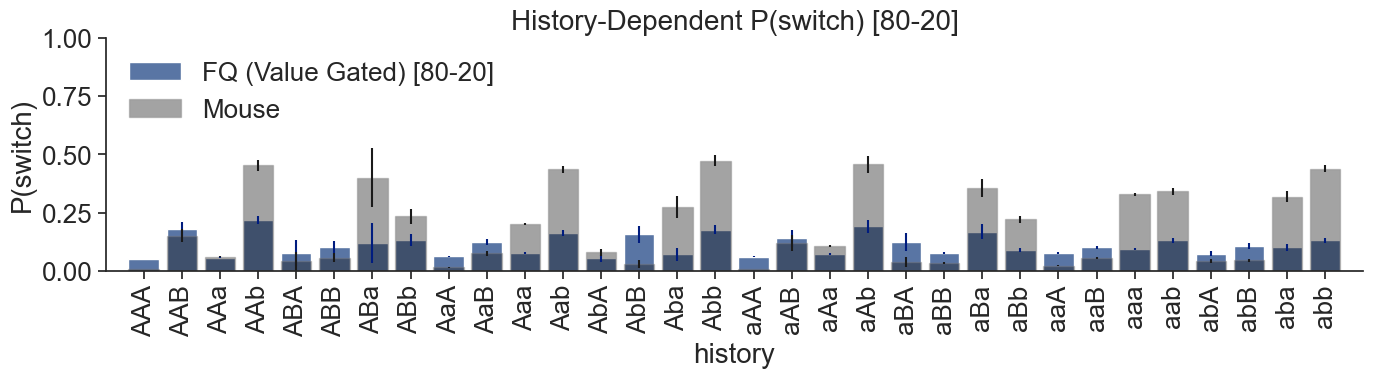


--- Processing Condition: 70-30 ---


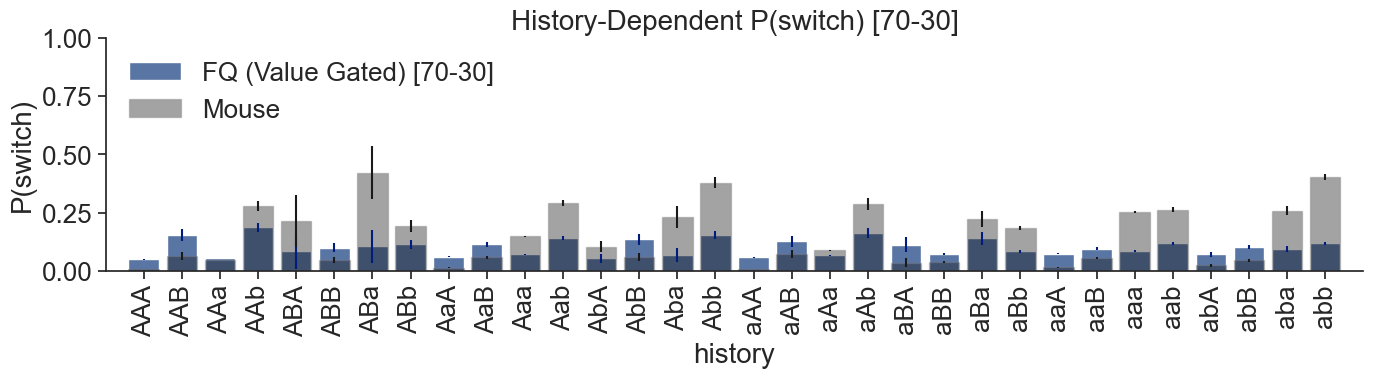


--- Generating Combined Plots (FQ) ---


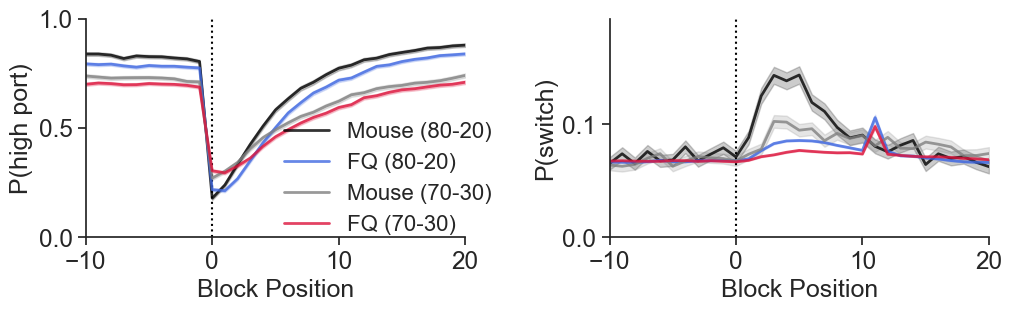

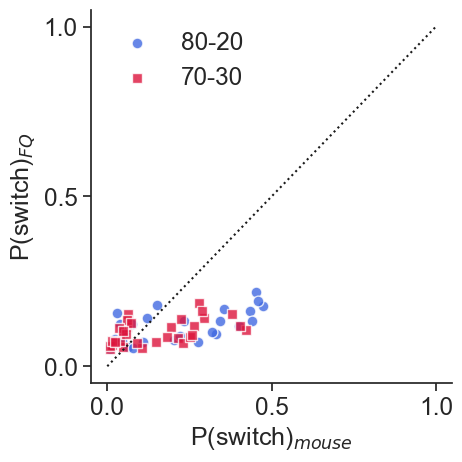

In [ ]:
# Containers to accumulate data for the combined plots
all_bpos_fq = []
hist_data_fq = {}


# LOOP THROUGH CONDITIONS

for condition_to_plot in ["80-20", "70-30"]:
    print(f"\n--- Processing Condition: {condition_to_plot} ---")

    # 1. Prepare Data & Strict Alignment
    df_mouse = df[df["Condition"] == condition_to_plot].copy()

    df_mouse["block_pos_rev"] = df_mouse["blockTrial"] - df_mouse["blockLength"]
    df_mouse["highPort"] = (df_mouse["Decision"] == df_mouse["Target"]).astype(int)

    # Extract FQ Optimal Parameters
    tau_val = df_cv[df_cv["Condition"] == condition_to_plot]["Tau"].mean()
    p_dyn = df_p4[
        (df_p4["Condition"] == condition_to_plot) & (df_p4["Model"] == "FQ_Value_Gated")
    ].iloc[0]

    session_list = df_mouse["Session"].unique()
    strict_sessions = []
    for sess in session_list:
        sess_df = df_mouse[(df_mouse["Session"] == sess) & df_mouse["Decision"].notna()]
        c = sess_df["Decision"].astype(int).values
        r = sess_df["Reward"].astype(int).values
        strict_sessions.append((c, r))

    # 2. Generate Predictive Policies (FQ Specific)
    # k is derived directly from the population-fitted Tau
    k_val = 1.0 - np.exp(-1.0 / tau_val)
    fq_params = (p_dyn["Alpha_base"], k_val, 1.0)

    res = run_fq_value_gated_only(
        strict_sessions,
        fq_params,
        int(p_dyn["N_steps"]),
        gamma=0.0,  # FQ does not use surprise-driven gamma gating
        fit_mode=True,
    )
    policies = res["policies"]

    # 3. Map Probabilities (100% Guaranteed Alignment)
    df_model = df_mouse.copy()
    df_model["p_right"] = np.nan

    policy_idx = 0
    for sess in session_list:
        sess_mask = (df_model["Session"] == sess) & df_model["Decision"].notna()
        valid_row_indices = df_model[sess_mask].index
        df_model.loc[valid_row_indices, "p_right"] = policies[policy_idx][:, 1]
        policy_idx += 1

    df_model = df_model.dropna(subset=["p_right"]).copy()
    df_mouse = df_mouse.loc[df_model.index].copy()

    # Calculate Expectations
    p_right_safe = df_model["p_right"].values
    p_left_safe = 1.0 - p_right_safe
    target_port = df_model["Target"].values
    df_model["highPort"] = np.where(target_port == 1, p_right_safe, p_left_safe)

    prev_choice = df_model["Decision"].shift(1).fillna(0).values
    df_model["Switch"] = np.where(prev_choice == 1, p_left_safe, p_right_safe)

    # 4. Save Plot 1 Data for Later Merging
    bpos_mouse = pmm.get_block_position_summaries(df_mouse)
    bpos_mouse["Group"] = f"Mouse ({condition_to_plot})"
    bpos_model = pmm.get_block_position_summaries(df_model)
    bpos_model["Group"] = f"FQ ({condition_to_plot})"
    all_bpos_fq.extend([bpos_mouse, bpos_model])

    # 5. Process History Data
    df_mouse_hist = cp.add_history_cols(df_mouse, N=3)
    df_model_hist = cp.add_history_cols(df_model, N=3)

    df_hist_mouse = cp.calc_conditional_probs(
        df_mouse_hist, symm=True, action=["Switch"]
    )
    df_hist_model = cp.calc_conditional_probs(
        df_model_hist, symm=True, action=["Switch"]
    )

    df_hist_model = cp.sort_cprobs(df_hist_model, df_hist_mouse["history"].tolist())

    hist_data_fq[condition_to_plot] = (df_hist_mouse, df_hist_model)

    # PLOT 2: Separate per condition

    pmm.plot_sequences(
        df=df_hist_mouse,
        overlay=df_hist_model,
        main_label="Mouse",
        overlay_label=f"FQ (Value Gated) [{condition_to_plot}]",
        title=f"History-Dependent P(switch) [{condition_to_plot}]",
    )
    plt.savefig(
        os.path.join(
            fig_dir, f"History-Dependent P(switch)_FQ_[{condition_to_plot}].pdf"
        ),
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()


# COMBINED PLOTS (Outside the loop)

print("\n--- Generating Combined Plots (FQ) ---")
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# --- Plot 1: Combined Transition Dynamics ---
bpos_combined_fq = pd.concat(all_bpos_fq, ignore_index=True)

# Using distinctly different colors for 80-20 vs 70-30
color_dict_transitions_fq = {
    "Mouse (80-20)": "black",
    "FQ (80-20)": "royalblue",
    "Mouse (70-30)": "gray",
    "FQ (70-30)": "crimson",
}


pmm.plot_by_block_position(
    bpos_combined_fq, subset="Group", color_dict=color_dict_transitions_fq
)
plt.savefig(
    os.path.join(fig_dir, "Transition Dynamics: FQ (Value Gated) [80-20 & 70-30].pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# --- Plot 3: Combined P(switch) Scatter Correlation ---
plt.figure(figsize=(5, 5))
plt.plot([0, 1], [0, 1], ":k")  # Diagonal reference line

# Plot 80-20
df_m_80, df_mdl_80 = hist_data_fq["80-20"]
plt.scatter(
    df_m_80["pswitch"],
    df_mdl_80["pswitch"],
    color="royalblue",
    label="80-20",
    alpha=0.8,
    s=60,
    edgecolor="white",
)

# Plot 70-30
df_m_70, df_mdl_70 = hist_data_fq["70-30"]
plt.scatter(
    df_m_70["pswitch"],
    df_mdl_70["pswitch"],
    color="crimson",
    label="70-30",
    alpha=0.8,
    s=60,
    marker="s",
    edgecolor="white",
)

plt.xlabel("P(switch)$_{mouse}$")
plt.ylabel("P(switch)$_{FQ}$")
plt.xticks(np.arange(0, 1.1, 0.5))
plt.yticks(np.arange(0, 1.1, 0.5))
plt.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig(
    os.path.join(fig_dir, "P(switch) Correlation: Mouse vs FQ (Value Gated).pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

Simulating autonomous agents for 80-20...
Simulating autonomous agents for 70-30...

Plotting 80-20 Generative Transition Dynamics...


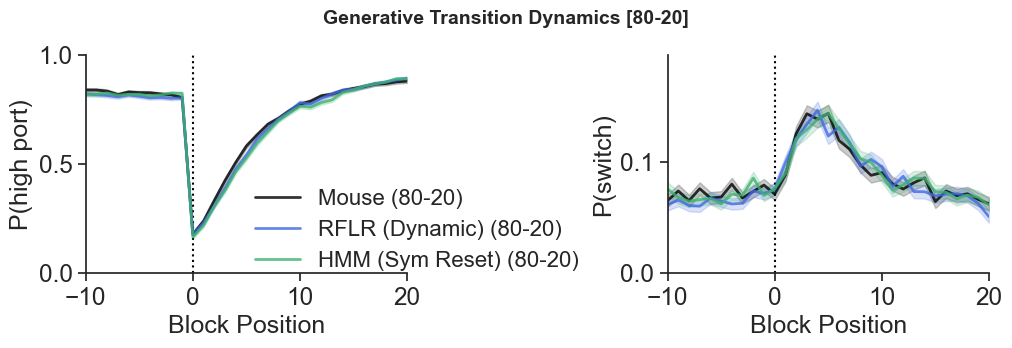

Plotting 70-30 Generative Transition Dynamics...


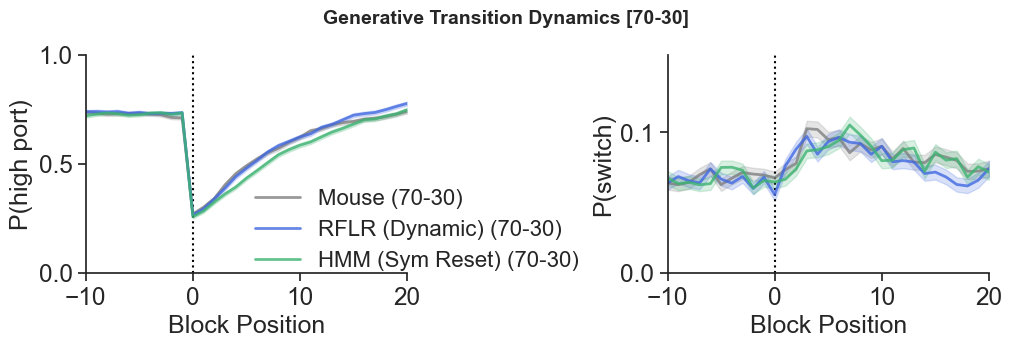


Finished! The predictive 'drag peak' is officially eliminated.


In [ ]:
np.random.seed(12)

all_bpos_comparison = []


# 1. RUN GENERATIVE SIMULATIONS

for condition in ["80-20", "70-30"]:
    print(f"Simulating autonomous agents for {condition}...")

    # --- A. Empirical Mouse Data ---
    df_mouse = df[df["Condition"] == condition].copy()
    df_mouse["block_pos_rev"] = df_mouse["blockTrial"] - df_mouse["blockLength"]
    df_mouse["highPort"] = (df_mouse["Decision"] == df_mouse["Target"]).astype(int)

    # Save Real Mouse Summaries
    bpos_mouse = pmm.get_block_position_summaries(df_mouse)
    bpos_mouse["Group"] = f"Mouse ({condition})"
    all_bpos_comparison.append(bpos_mouse)

    # Extract target structures & physical parameters
    session_list = df_mouse["Session"].unique()
    gen_targets = [
        df_mouse[df_mouse["Session"] == s]["Target"].values for s in session_list
    ]

    p_high = int(condition.split("-")[0]) / 100.0
    est_p_switch = 1.0 / np.mean(
        [len(t) / np.sum(np.abs(np.diff(t))) for t in gen_targets]
    )
    beta_val = df_cv[df_cv["Condition"] == condition]["Beta"].mean()
    tau_val = df_cv[df_cv["Condition"] == condition]["Tau"].mean()

    # --- B. RFLR (Dynamic) Generative ---
    p_rflr = df_p4[(df_p4["Condition"] == condition) & (df_p4["Model"] == "RFLR")].iloc[
        0
    ]
    rflr_sessions = simulate_rflr_dynamic_generative(
        gen_targets,
        p_high,
        p_rflr["Alpha_base"],
        beta_val,
        tau_val,
        p_rflr["Gamma"],
        int(p_rflr["N_steps"]),
    )

    df_rflr = df_mouse.copy()
    df_rflr["Decision"] = np.concatenate([c for c, r in rflr_sessions])

    # Calculate physical switches & high-port accuracy
    prev_rflr_choice = df_rflr["Decision"].shift(1)
    df_rflr["Switch"] = (df_rflr["Decision"] != prev_rflr_choice).astype(int)
    df_rflr.loc[df_rflr.groupby("Session").head(1).index, "Switch"] = 0
    df_rflr["highPort"] = (df_rflr["Decision"] == df_rflr["Target"]).astype(int)

    bpos_rflr = pmm.get_block_position_summaries(df_rflr)
    bpos_rflr["Group"] = f"RFLR (Dynamic) ({condition})"
    all_bpos_comparison.append(bpos_rflr)

    # --- C. HMM_resetv2 (Sym Reset) Generative ---
    p_hmm = df_p4[
        (df_p4["Condition"] == condition) & (df_p4["Model"] == "HMM_resetv2")
    ].iloc[0]
    hmm_sessions = simulate_hmm_reset_v2_generative(
        gen_targets,
        p_high,
        est_p_switch,
        p_hmm["Alpha_base"],
        beta_val,
        tau_val,
        p_hmm["Gamma"],
        int(p_hmm["N_steps"]),
    )

    df_hmm = df_mouse.copy()
    df_hmm["Decision"] = np.concatenate([c for c, r in hmm_sessions])

    # Calculate physical switches & high-port accuracy
    prev_hmm_choice = df_hmm["Decision"].shift(1)
    df_hmm["Switch"] = (df_hmm["Decision"] != prev_hmm_choice).astype(int)
    df_hmm.loc[df_hmm.groupby("Session").head(1).index, "Switch"] = 0
    df_hmm["highPort"] = (df_hmm["Decision"] == df_hmm["Target"]).astype(int)

    bpos_hmm = pmm.get_block_position_summaries(df_hmm)
    bpos_hmm["Group"] = f"HMM (Sym Reset) ({condition})"
    all_bpos_comparison.append(bpos_hmm)

# Combine everything
bpos_combined_all = pd.concat(all_bpos_comparison, ignore_index=True)


# 2. PLOT THE TRANSITION DYNAMICS (FIG 6B STYLE)

sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Define clean colors for the comparison
color_dict_6B = {
    "Mouse (80-20)": "black",
    "RFLR (Dynamic) (80-20)": "royalblue",
    "HMM (Sym Reset) (80-20)": "mediumseagreen",
    "Mouse (70-30)": "gray",
    "RFLR (Dynamic) (70-30)": "royalblue",
    "HMM (Sym Reset) (70-30)": "mediumseagreen",
}

# --- Plot 80-20 Condition ---
print("\nPlotting 80-20 Generative Transition Dynamics...")
bpos_80 = bpos_combined_all[bpos_combined_all["Group"].str.contains("80-20")]

pmm.plot_by_block_position(bpos_80, subset="Group", color_dict=color_dict_6B)
plt.suptitle(
    "Generative Transition Dynamics [80-20]", y=1.02, fontsize=14, fontweight="bold"
)
plt.savefig(
    os.path.join(fig_dir, "Transition_Dynamics_Generative_[80-20].pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()

# --- Plot 70-30 Condition ---
print("Plotting 70-30 Generative Transition Dynamics...")
bpos_70 = bpos_combined_all[bpos_combined_all["Group"].str.contains("70-30")]

pmm.plot_by_block_position(bpos_70, subset="Group", color_dict=color_dict_6B)
plt.suptitle(
    "Generative Transition Dynamics [70-30]", y=1.02, fontsize=14, fontweight="bold"
)
plt.savefig(
    os.path.join(fig_dir, "Transition_Dynamics_Generative_[70-30].pdf"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()